# Cinnamon Oil Classification
**Target:** `result` — 7 classes: `bark_superior`, `bark_special`, `bark_average`, `bark_ordinary`, `leaf_pass`, `leaf_fail`, `adulterated`  
**Features:** `density` (primary), `ph_value`, + optional image  
**Upload required:**
- `input.csv` → `/content/input.csv`
- `images.zip` → `/content/images.zip` *(optional — tabular model runs without images)*

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Install packages

In [14]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost catboost tensorflow pillow joblib

## 2. Import libraries

In [15]:
import os
import json
import zipfile
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 3. Configuration

In [16]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATASET_PATH = '/content/input.csv'
ZIP_PATH     = '/content/images.zip'
EXTRACT_DIR  = '/content/extracted_images'
OUTPUT_DIR   = '/content/outputs'
MODEL_DIR    = '/content/models'

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

# ── Fixed column names ─────────────────────────────────────────────────────
IMAGE_COLUMN      = 'image_name'          # column that holds the image filename
TARGET_COLUMN     = 'result'              # what we are predicting
NUMERICAL_FEATURES = ['density', 'ph_value']   # tabular features used by ML models

# ── 7 output classes (order matters for the label encoder) ─────────────────
CLASS_NAMES = [
    'bark_superior',
    'bark_special',
    'bark_average',
    'bark_ordinary',
    'leaf_pass',
    'leaf_fail',
    'adulterated',
]

# ── Training hyper-parameters ──────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
IMG_SIZE     = 224
BATCH_SIZE   = 8
EPOCHS       = 30

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('Configuration set.')
print('Target column   :', TARGET_COLUMN)
print('Image column    :', IMAGE_COLUMN)
print('Tabular features:', NUMERICAL_FEATURES)
print('Classes         :', CLASS_NAMES)

Configuration set.
Target column   : result
Image column    : image_name
Tabular features: ['density', 'ph_value']
Classes         : ['bark_superior', 'bark_special', 'bark_average', 'bark_ordinary', 'leaf_pass', 'leaf_fail', 'adulterated']


## 4. Extract images (optional)

In [17]:
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Images extracted to:', EXTRACT_DIR)
else:
    print('images.zip not found — image & hybrid models will be skipped.')
    print('Only tabular models (RandomForest / XGBoost / CatBoost) will run.')

Images extracted to: /content/extracted_images


## 5. Collect extracted image paths

In [18]:
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff')

image_lookup = {}   # filename → full path

for root, _, files in os.walk(EXTRACT_DIR):
    for fname in files:
        if fname.lower().endswith(IMAGE_EXTENSIONS):
            image_lookup[fname] = os.path.join(root, fname)

print('Total images found:', len(image_lookup))
if image_lookup:
    print('First 5:', list(image_lookup.keys())[:5])

Total images found: 1400
First 5: ['sample_195.jpg', 'sample_086.jpg', 'sample_233.jpg', 'sample_323.jpg', 'sample_670.jpg']


## 6. Load dataset

In [19]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'CSV not found at: {DATASET_PATH}\nPlease upload input.csv to /content/')

df = pd.read_csv(DATASET_PATH)

# Verify expected columns exist
required_cols = [IMAGE_COLUMN, TARGET_COLUMN] + NUMERICAL_FEATURES
missing_cols  = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns in CSV: {missing_cols}\nFound: {df.columns.tolist()}')

print('Dataset loaded — shape:', df.shape)
display(df.head())

Dataset loaded — shape: (700, 4)


,image_name,density,ph_value,result
0,sample_001,1.042,5.35,bark_superior
1,sample_002,1.040,5.38,bark_superior
2,sample_003,1.043,5.45,bark_superior
3,sample_004,1.044,5.36,bark_superior
4,sample_005,1.041,5.35,bark_superior


## 7. Validate classes

In [20]:
actual_classes = sorted(df[TARGET_COLUMN].dropna().unique().tolist())
expected_classes = sorted(CLASS_NAMES)

print('Classes in CSV  :', actual_classes)
print('Expected classes:', expected_classes)

extra    = set(actual_classes) - set(expected_classes)
missing  = set(expected_classes) - set(actual_classes)

if extra:
    print(f'WARNING — unexpected class values found: {extra}')
if missing:
    print(f'INFO — classes not in this dataset: {missing}')
if not extra and not missing:
    print('All classes match.')

Classes in CSV  : ['adulterated', 'bark_average', 'bark_ordinary', 'bark_special', 'bark_superior', 'leaf_fail', 'leaf_pass']
Expected classes: ['adulterated', 'bark_average', 'bark_ordinary', 'bark_special', 'bark_superior', 'leaf_fail', 'leaf_pass']
All classes match.


## 8. Attach image paths and clean data

In [21]:
def find_image_path(image_name):
    """Return full disk path for an image filename, or None if not found."""
    if pd.isna(image_name):
        return None
    base = os.path.basename(str(image_name))
    # Try exact match first, then with common extensions
    if base in image_lookup:
        return image_lookup[base]
    for ext in IMAGE_EXTENSIONS:
        candidate = base + ext
        if candidate in image_lookup:
            return image_lookup[candidate]
    return None

df['image_path']   = df[IMAGE_COLUMN].apply(find_image_path)
df['image_exists'] = df['image_path'].notnull()

# Drop rows with missing target or missing numerical features
df_clean = df.dropna(subset=[TARGET_COLUMN] + NUMERICAL_FEATURES).copy()
df_image_clean = df_clean[df_clean['image_exists']].copy()

print('Total rows           :', len(df))
print('After dropping nulls :', len(df_clean))
print('Rows with images     :', len(df_image_clean))
print('Rows without images  :', len(df_clean) - len(df_image_clean))

display(df_clean.head())

Total rows           : 700
After dropping nulls : 700
Rows with images     : 700
Rows without images  : 0


,image_name,density,ph_value,result,image_path,image_exists
0,sample_001,1.042,5.35,bark_superior,/content/extracted_images/input_images/sample_...,True
1,sample_002,1.040,5.38,bark_superior,/content/extracted_images/input_images/sample_...,True
2,sample_003,1.043,5.45,bark_superior,/content/extracted_images/input_images/sample_...,True
3,sample_004,1.044,5.36,bark_superior,/content/extracted_images/input_images/sample_...,True
4,sample_005,1.041,5.35,bark_superior,/content/extracted_images/input_images/sample_...,True


## 9. EDA — class distribution

Class distribution:
result
bark_superior    100
bark_special     100
bark_average     100
bark_ordinary    100
leaf_pass        100
leaf_fail        100
adulterated      100
Name: count, dtype: int64


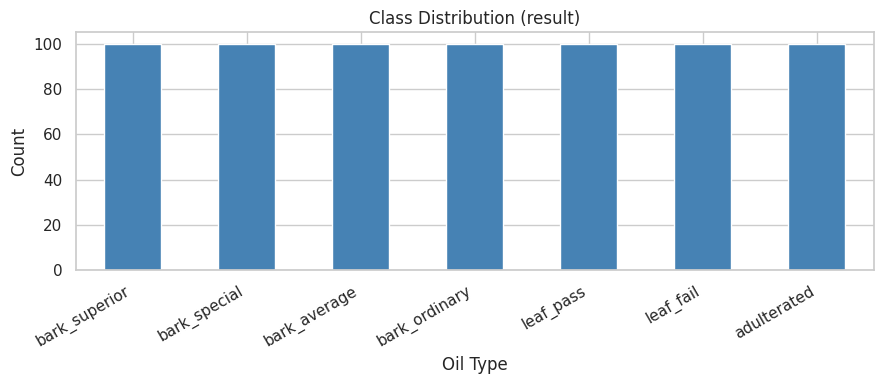

In [22]:
print('Class distribution:')
print(df_clean[TARGET_COLUMN].value_counts())

plt.figure(figsize=(9, 4))
df_clean[TARGET_COLUMN].value_counts().reindex(CLASS_NAMES, fill_value=0).plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title('Class Distribution (result)')
plt.ylabel('Count')
plt.xlabel('Oil Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. EDA — density distribution by class

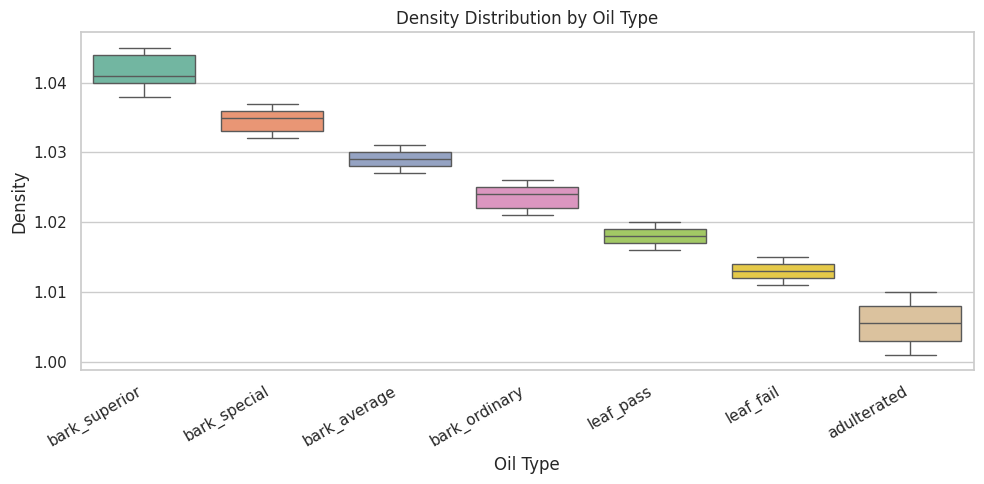

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x=TARGET_COLUMN,
    y='density',
    order=CLASS_NAMES,
    palette='Set2'
)
plt.title('Density Distribution by Oil Type')
plt.xlabel('Oil Type')
plt.ylabel('Density')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 11. EDA — ph_value distribution by class

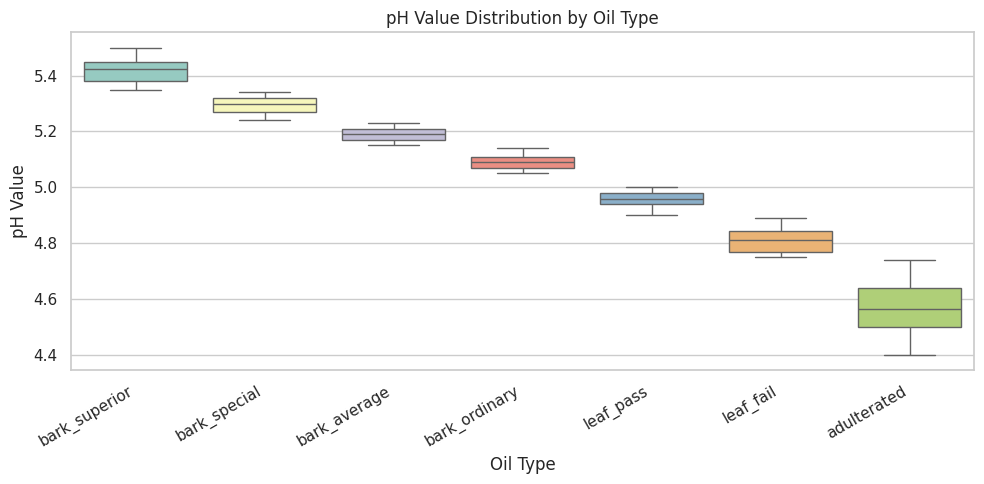

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x=TARGET_COLUMN,
    y='ph_value',
    order=CLASS_NAMES,
    palette='Set3'
)
plt.title('pH Value Distribution by Oil Type')
plt.xlabel('Oil Type')
plt.ylabel('pH Value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12. EDA — scatter: density vs ph_value coloured by class

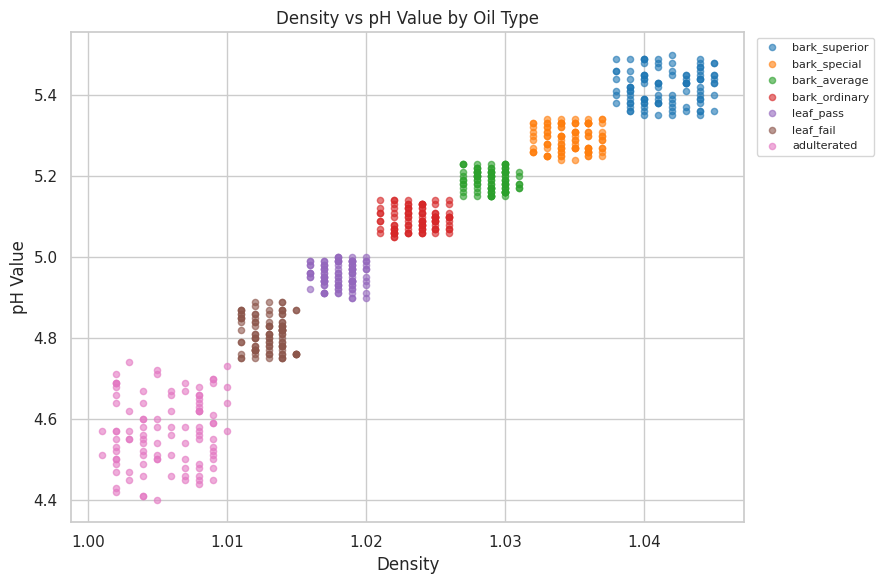

In [25]:
plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', n_colors=len(CLASS_NAMES))
color_map = dict(zip(CLASS_NAMES, palette))

for cls in CLASS_NAMES:
    subset = df_clean[df_clean[TARGET_COLUMN] == cls]
    plt.scatter(
        subset['density'],
        subset['ph_value'],
        label=cls,
        color=color_map[cls],
        alpha=0.6,
        s=20
    )

plt.xlabel('Density')
plt.ylabel('pH Value')
plt.title('Density vs pH Value by Oil Type')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 13. EDA — missing values

In [26]:
mv = df_clean.isnull().sum()
mv = mv[mv > 0]

if len(mv) == 0:
    print('No missing values in cleaned dataset.')
else:
    print('Missing values:')
    print(mv)
    mv.plot(kind='bar')
    plt.title('Missing Values')
    plt.tight_layout()
    plt.show()

print('Duplicate rows:', df_clean.duplicated().sum())

No missing values in cleaned dataset.
Duplicate rows: 0


## 14. Image preview (if images available)

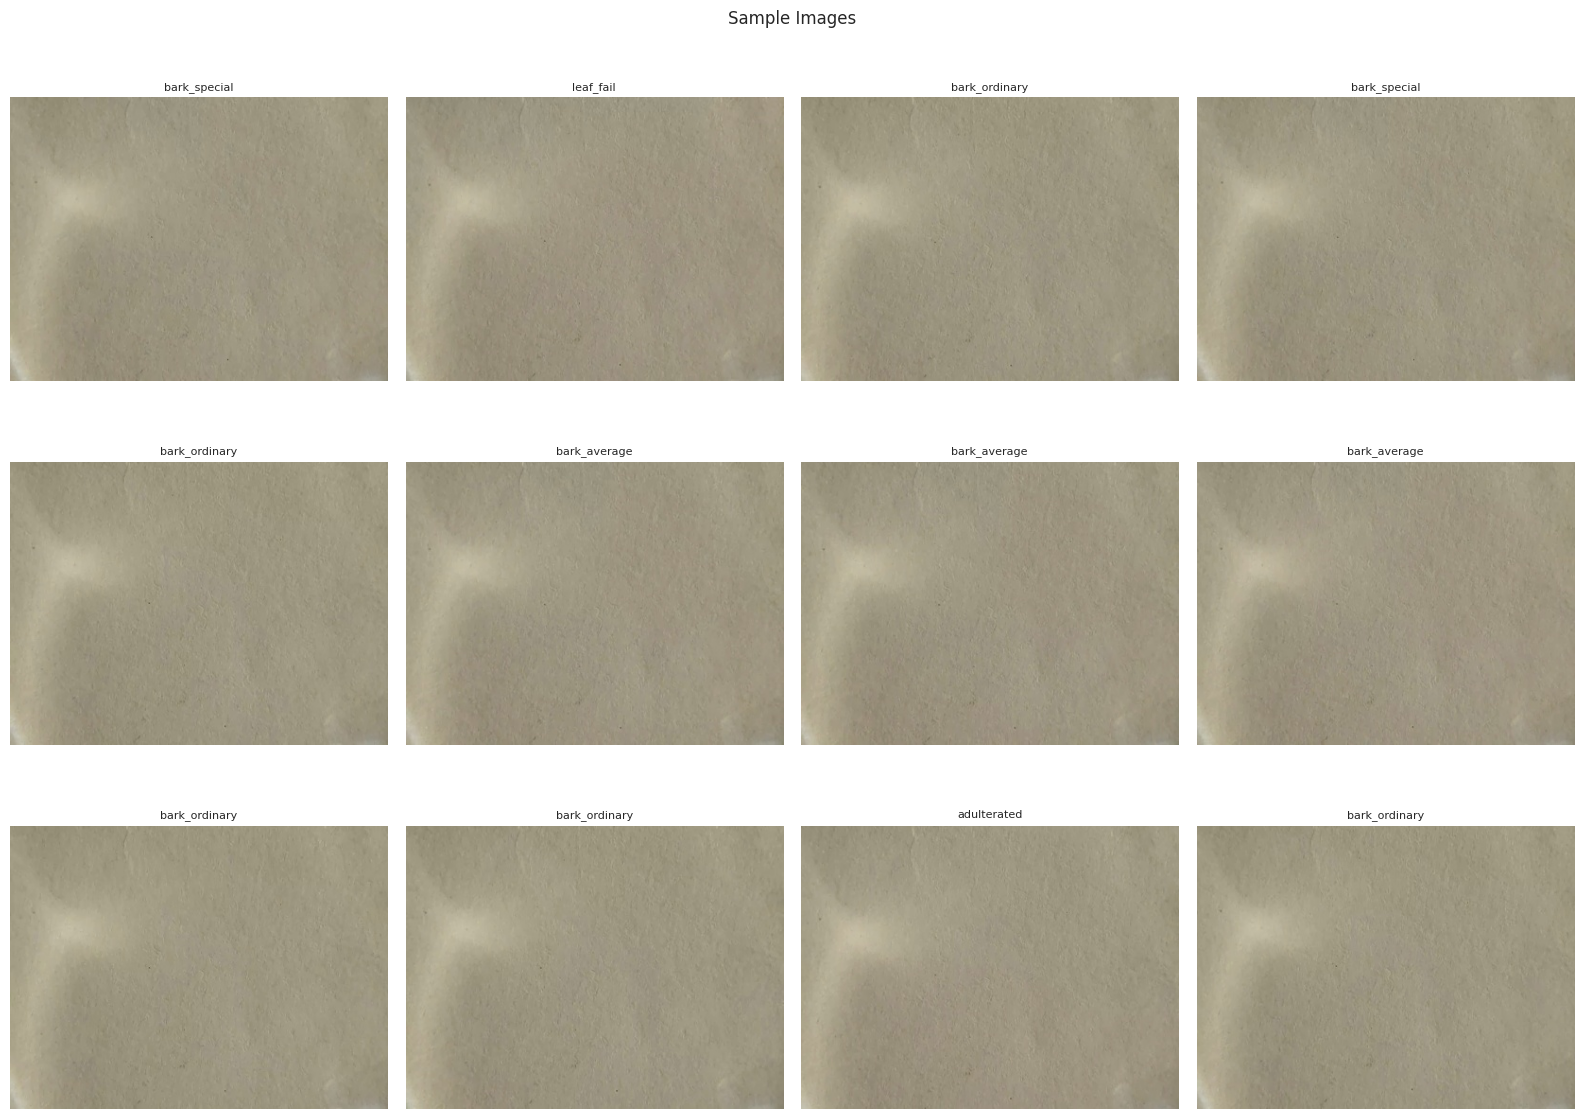

In [27]:
if len(df_image_clean) > 0:
    sample = df_image_clean.sample(min(12, len(df_image_clean)), random_state=RANDOM_STATE)
    cols_n = 4
    rows_n = (len(sample) + cols_n - 1) // cols_n

    plt.figure(figsize=(cols_n * 4, rows_n * 4))
    for i, (_, row) in enumerate(sample.iterrows()):
        try:
            img = Image.open(row['image_path']).convert('RGB')
            plt.subplot(rows_n, cols_n, i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(row[TARGET_COLUMN], fontsize=8)
        except Exception as e:
            print('Could not load:', row['image_path'], e)

    plt.suptitle('Sample Images', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No images available for preview.')

## 15. Encode target labels

In [28]:
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_NAMES)          # fit on ALL 7 classes so encoding is stable

df_clean['target_encoded'] = label_encoder.transform(df_clean[TARGET_COLUMN].astype(str))

NUM_CLASSES = len(label_encoder.classes_)

joblib.dump(label_encoder, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print('Label encoder classes:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {i} → {cls}')

Label encoder classes:
  0 → adulterated
  1 → bark_average
  2 → bark_ordinary
  3 → bark_special
  4 → bark_superior
  5 → leaf_fail
  6 → leaf_pass


## 16. Tabular train/validation split

In [29]:
X_tabular = df_clean[NUMERICAL_FEATURES].copy()
y_encoded = df_clean['target_encoded'].values

X_train_tab, X_val_tab, y_train, y_val = train_test_split(
    X_tabular, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print('Train set:', X_train_tab.shape, '| Validation set:', X_val_tab.shape)

Train set: (560, 2) | Validation set: (140, 2)


## 17. Build tabular preprocessing pipeline

In [30]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, NUMERICAL_FEATURES)],
    remainder='drop'
)

metadata = {
    'target_column'     : TARGET_COLUMN,
    'image_column'      : IMAGE_COLUMN,
    'numerical_features': NUMERICAL_FEATURES,
    'class_names'       : CLASS_NAMES,
    'problem_type'      : 'classification',
}

joblib.dump(metadata, os.path.join(MODEL_DIR, 'metadata.pkl'))
print('Metadata saved.')

Metadata saved.


## 18. Evaluation helper

In [31]:
def evaluate_classification(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')

    print(f'\n{model_name} — Classification Results')
    print('-' * 55)
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Weighted F1     : {f1:.4f}')
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_
    ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'f1': f1}

print('Helper functions ready.')

Helper functions ready.


## 19. Train tabular models (RandomForest / XGBoost / CatBoost)

Training RandomForest...

RandomForest — Classification Results
-------------------------------------------------------
  Accuracy        : 1.0000
  Weighted F1     : 1.0000

               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00        20
 bark_average       1.00      1.00      1.00        20
bark_ordinary       1.00      1.00      1.00        20
 bark_special       1.00      1.00      1.00        20
bark_superior       1.00      1.00      1.00        20
    leaf_fail       1.00      1.00      1.00        20
    leaf_pass       1.00      1.00      1.00        20

     accuracy                           1.00       140
    macro avg       1.00      1.00      1.00       140
 weighted avg       1.00      1.00      1.00       140



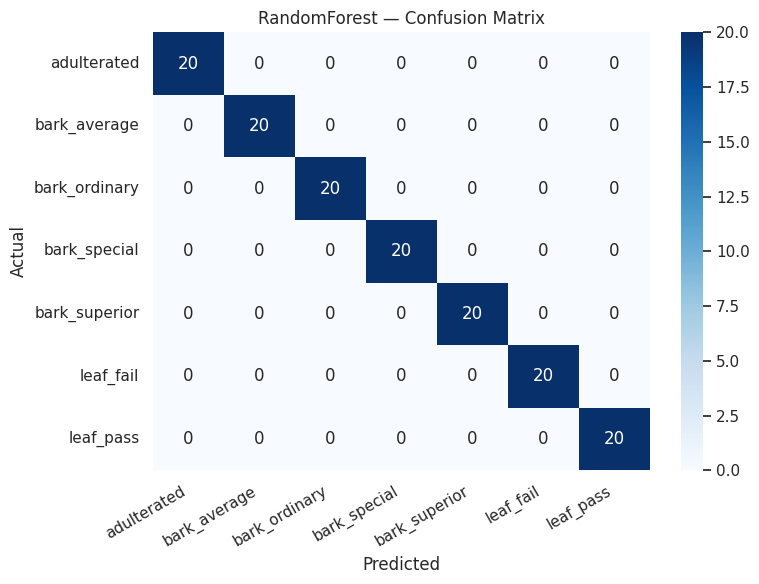

Training XGBoost...

XGBoost — Classification Results
-------------------------------------------------------
  Accuracy        : 1.0000
  Weighted F1     : 1.0000

               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00        20
 bark_average       1.00      1.00      1.00        20
bark_ordinary       1.00      1.00      1.00        20
 bark_special       1.00      1.00      1.00        20
bark_superior       1.00      1.00      1.00        20
    leaf_fail       1.00      1.00      1.00        20
    leaf_pass       1.00      1.00      1.00        20

     accuracy                           1.00       140
    macro avg       1.00      1.00      1.00       140
 weighted avg       1.00      1.00      1.00       140



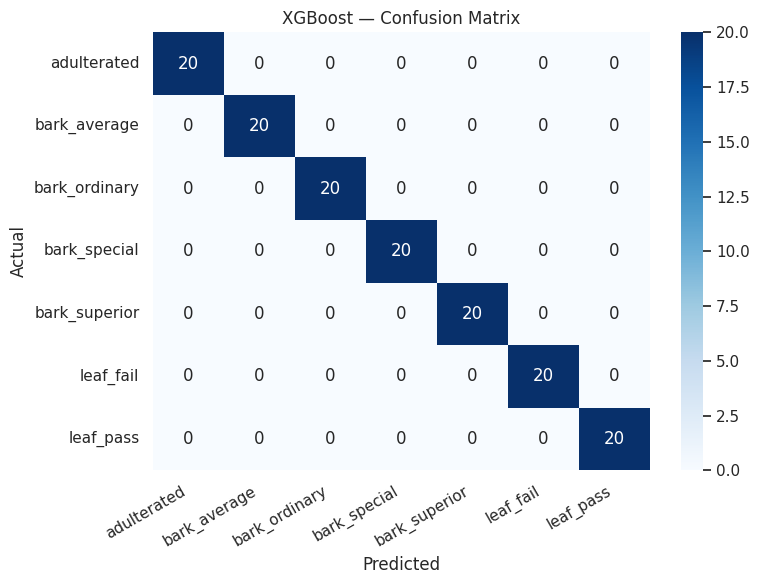

Training CatBoost...

CatBoost — Classification Results
-------------------------------------------------------
  Accuracy        : 1.0000
  Weighted F1     : 1.0000

               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00        20
 bark_average       1.00      1.00      1.00        20
bark_ordinary       1.00      1.00      1.00        20
 bark_special       1.00      1.00      1.00        20
bark_superior       1.00      1.00      1.00        20
    leaf_fail       1.00      1.00      1.00        20
    leaf_pass       1.00      1.00      1.00        20

     accuracy                           1.00       140
    macro avg       1.00      1.00      1.00       140
 weighted avg       1.00      1.00      1.00       140



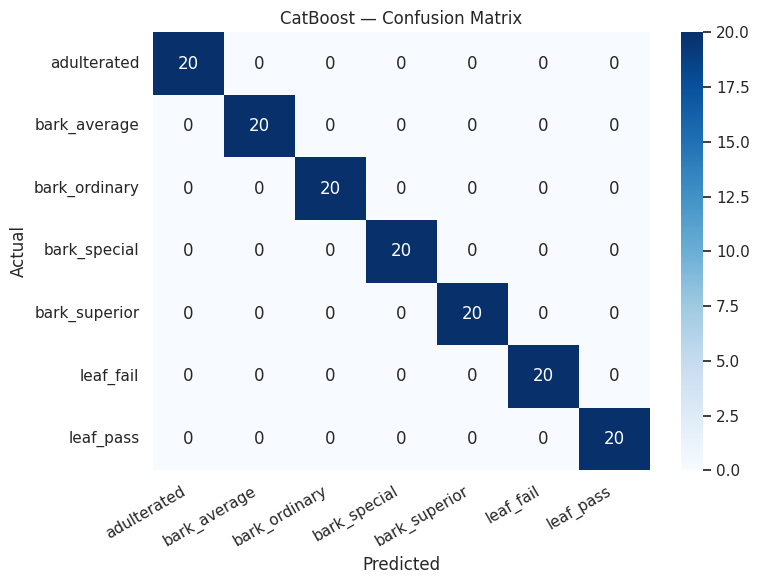

,model,accuracy,f1
0,RandomForest,1.0,1.0
1,XGBoost,1.0,1.0
2,CatBoost,1.0,1.0


In [32]:
models_to_train = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=NUM_CLASSES,
        use_label_encoder=False
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.03,
        depth=5,
        loss_function='MultiClass',
        random_seed=RANDOM_STATE,
        verbose=False
    ),
}

tabular_results        = []
trained_tabular_models = {}

for model_name, base_model in models_to_train.items():
    print(f'Training {model_name}...')

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model',        base_model)
    ])

    pipeline.fit(X_train_tab, y_train)
    y_pred = pipeline.predict(X_val_tab)

    result = evaluate_classification(y_val, y_pred, model_name)
    tabular_results.append(result)
    trained_tabular_models[model_name] = pipeline

tabular_results_df = pd.DataFrame(tabular_results)
display(tabular_results_df)

## 20. Select best tabular model

In [33]:
best_row                = tabular_results_df.sort_values('f1', ascending=False).iloc[0]
best_tabular_model_name = best_row['model']
best_tabular_model      = trained_tabular_models[best_tabular_model_name]

print('Best tabular model:', best_tabular_model_name)
print(f'  Accuracy: {best_row["accuracy"]:.4f}  |  F1: {best_row["f1"]:.4f}')

joblib.dump(best_tabular_model, os.path.join(MODEL_DIR, 'best_tabular_model.pkl'))
print('Saved → /content/models/best_tabular_model.pkl')

Best tabular model: RandomForest
  Accuracy: 1.0000  |  F1: 1.0000
Saved → /content/models/best_tabular_model.pkl


## 21. Feature importance

Feature importances:


,feature,importance
1,ph_value,0.510402
0,density,0.489598


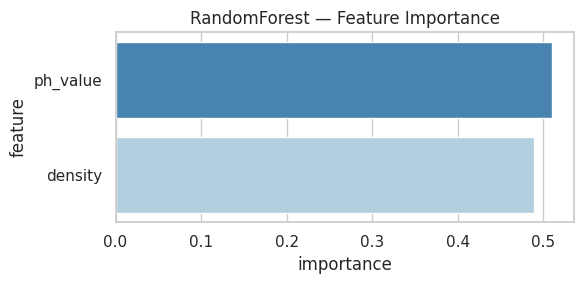

In [34]:
try:
    fitted_model = best_tabular_model.named_steps['model']

    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
        imp_df = pd.DataFrame({
            'feature'   : NUMERICAL_FEATURES,
            'importance': importances
        }).sort_values('importance', ascending=False)

        print('Feature importances:')
        display(imp_df)

        plt.figure(figsize=(6, 3))
        sns.barplot(data=imp_df, x='importance', y='feature', palette='Blues_r')
        plt.title(f'{best_tabular_model_name} — Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{best_tabular_model_name} does not expose feature_importances_.')
except Exception as e:
    print('Could not compute feature importances:', e)

## 22. Image model — data preparation

In [35]:
USE_IMAGE_MODEL = len(df_image_clean) >= 20
print('Use image model:', USE_IMAGE_MODEL)

if not USE_IMAGE_MODEL:
    print(f'Only {len(df_image_clean)} images found — need at least 20. Skipping image model.')

if USE_IMAGE_MODEL:
    img_df = df_image_clean.copy()
    img_target = label_encoder.transform(img_df[TARGET_COLUMN].astype(str))

    train_img_df, val_img_df = train_test_split(
        img_df, test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=img_target
    )

    print('Image train:', train_img_df.shape, '| Val:', val_img_df.shape)

Use image model: True
Image train: (560, 6) | Val: (140, 6)


## 23. Image model — tf.data datasets

In [36]:
def load_and_preprocess_image(path, target):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, target

def make_image_dataset(dataframe, shuffle=True):
    paths   = dataframe['image_path'].values
    targets = label_encoder.transform(dataframe[TARGET_COLUMN].astype(str))
    ds = tf.data.Dataset.from_tensor_slices((paths, targets.astype(np.int32)))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=RANDOM_STATE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

if USE_IMAGE_MODEL:
    train_img_ds = make_image_dataset(train_img_df, shuffle=True)
    val_img_ds   = make_image_dataset(val_img_df,   shuffle=False)
    print('Image datasets created.')

Image datasets created.


## 24. Image model — build

In [37]:
def build_image_model():
    augmentation = tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    inputs   = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x        = augmentation(inputs)

    base     = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    # 7-class softmax
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

if USE_IMAGE_MODEL:
    image_model = build_image_model()
    image_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,954 (16.08 MB)

 Trainable params: 165,127 (645.03 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

## 25. Image model — train

In [38]:
image_history = None

if USE_IMAGE_MODEL:
    img_model_path = os.path.join(MODEL_DIR, 'best_image_model.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ModelCheckpoint(img_model_path, monitor='val_loss', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    ]

    image_history = image_model.fit(
        train_img_ds,
        validation_data=val_img_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    image_model = tf.keras.models.load_model(img_model_path)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.1464 - loss: 2.4791 - val_accuracy: 0.1429 - val_loss: 1.9648 - learning_rate: 3.0000e-04
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.1571 - loss: 2.3355 - val_accuracy: 0.1429 - val_loss: 1.9508 - learning_rate: 3.0000e-04
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.1446 - loss: 2.2966 - val_accuracy: 0.1429 - val_loss: 1.9736 - learning_rate: 3.0000e-04
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.1357 - loss: 2.2648 - val_accuracy: 0.1429 - val_loss: 1.9621 - learning_rate: 3.0000e-04
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.1500 - loss: 2.2608 - val_accuracy: 0.1429 - val_loss: 2.0042 - learning_rate: 3.0000e-04
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0929 - loss: 2.3260 - val_accuracy: 0.1429 - val_loss: 1.9790 - learning_rate: 9.0000e-05
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.166

## 26. Image model — training curves

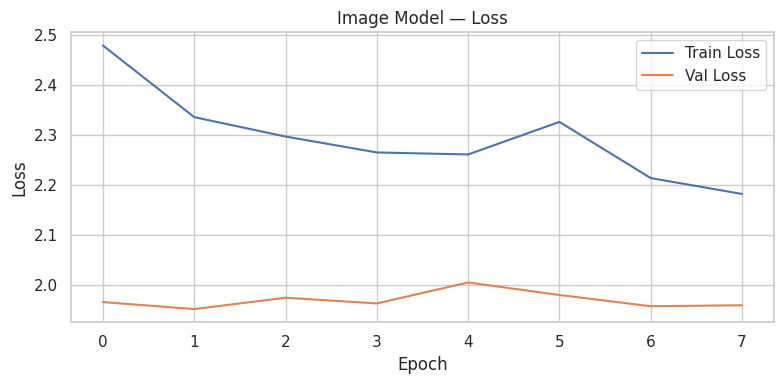

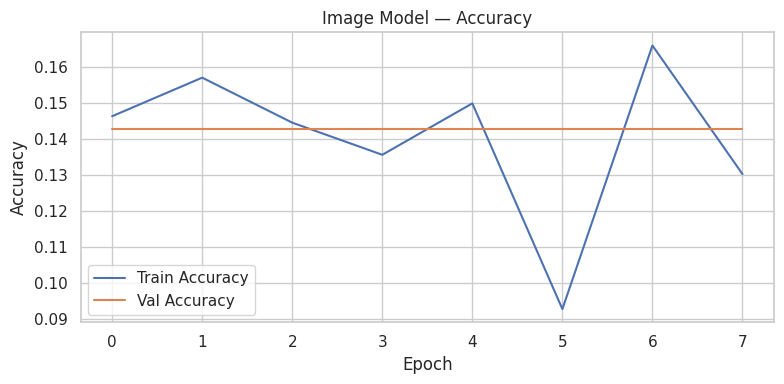

In [39]:
def plot_history(history, title_prefix):
    if history is None:
        return
    h = history.history

    plt.figure(figsize=(8, 4))
    plt.plot(h['loss'], label='Train Loss')
    plt.plot(h['val_loss'], label='Val Loss')
    plt.title(f'{title_prefix} — Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.tight_layout(); plt.show()

    if 'accuracy' in h:
        plt.figure(figsize=(8, 4))
        plt.plot(h['accuracy'], label='Train Accuracy')
        plt.plot(h['val_accuracy'], label='Val Accuracy')
        plt.title(f'{title_prefix} — Accuracy')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy')
        plt.legend(); plt.tight_layout(); plt.show()

plot_history(image_history, 'Image Model')

## 27. Image model — evaluate

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step

Image Model — Classification Results
-------------------------------------------------------
  Accuracy        : 0.1429
  Weighted F1     : 0.0357

               precision    recall  f1-score   support

  adulterated       0.00      0.00      0.00        20
 bark_average       0.00      0.00      0.00        20
bark_ordinary       0.00      0.00      0.00        20
 bark_special       0.00      0.00      0.00        20
bark_superior       0.00      0.00      0.00        20
    leaf_fail       0.00      0.00      0.00        20
    leaf_pass       0.14      1.00      0.25        20

     accuracy                           0.14       140
    macro avg       0.02      0.14      0.04       140
 weighted avg       0.02      0.14      0.04       140



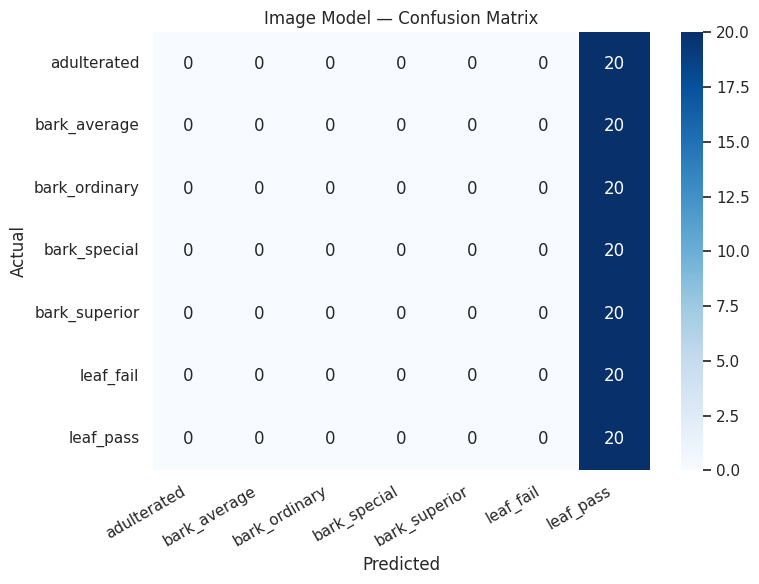

In [40]:
image_result = None

if USE_IMAGE_MODEL:
    y_val_img_true  = label_encoder.transform(val_img_df[TARGET_COLUMN].astype(str))
    img_preds_raw   = image_model.predict(val_img_ds)
    img_preds       = np.argmax(img_preds_raw, axis=1)

    image_result = evaluate_classification(y_val_img_true, img_preds, 'Image Model')
else:
    print('Image model skipped.')

## 28. Hybrid model — preparation

In [41]:
USE_HYBRID_MODEL = USE_IMAGE_MODEL and len(NUMERICAL_FEATURES) > 0
print('Use hybrid model:', USE_HYBRID_MODEL)

if USE_HYBRID_MODEL:
    hybrid_df     = df_image_clean.copy()
    hybrid_target = label_encoder.transform(hybrid_df[TARGET_COLUMN].astype(str))

    train_hybrid_df, val_hybrid_df = train_test_split(
        hybrid_df, test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=hybrid_target
    )

    # Fit a fresh preprocessor for the hybrid branch
    hybrid_preprocessor = ColumnTransformer(
        transformers=[('num', numeric_transformer, NUMERICAL_FEATURES)],
        remainder='drop'
    )

    X_train_h_tab = hybrid_preprocessor.fit_transform(
        train_hybrid_df[NUMERICAL_FEATURES]
    ).astype(np.float32)

    X_val_h_tab   = hybrid_preprocessor.transform(
        val_hybrid_df[NUMERICAL_FEATURES]
    ).astype(np.float32)

    joblib.dump(hybrid_preprocessor,
                os.path.join(MODEL_DIR, 'hybrid_tabular_preprocessor.pkl'))

    print('Hybrid tabular train:', X_train_h_tab.shape)
    print('Hybrid tabular val  :', X_val_h_tab.shape)

Use hybrid model: True
Hybrid tabular train: (560, 2)
Hybrid tabular val  : (140, 2)


## 29. Hybrid model — load image arrays

In [42]:
def load_image_array(path):
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    return np.array(img, dtype=np.float32) / 255.0

def load_image_arrays(paths):
    return np.array([load_image_array(p) for p in paths], dtype=np.float32)

if USE_HYBRID_MODEL:
    X_train_h_img = load_image_arrays(train_hybrid_df['image_path'].values)
    X_val_h_img   = load_image_arrays(val_hybrid_df['image_path'].values)

    y_train_hybrid = label_encoder.transform(train_hybrid_df[TARGET_COLUMN].astype(str))
    y_val_hybrid   = label_encoder.transform(val_hybrid_df[TARGET_COLUMN].astype(str))

    print('Hybrid image train:', X_train_h_img.shape)
    print('Hybrid image val  :', X_val_h_img.shape)

Hybrid image train: (560, 224, 224, 3)
Hybrid image val  : (140, 224, 224, 3)


## 30. Hybrid model — build

In [43]:
def build_hybrid_model(tabular_dim):
    augmentation = tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    x_img     = augmentation(img_input)

    base = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    x_img = base(x_img, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dropout(0.35)(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.BatchNormalization()(x_img)

    tab_input = layers.Input(shape=(tabular_dim,), name='tabular_input')
    x_tab     = layers.Dense(64, activation='relu')(tab_input)
    x_tab     = layers.BatchNormalization()(x_tab)
    x_tab     = layers.Dropout(0.25)(x_tab)
    x_tab     = layers.Dense(32, activation='relu')(x_tab)

    combined = layers.concatenate([x_img, x_tab])
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.25)(x)

    # 7-class softmax
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=[img_input, tab_input], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

if USE_HYBRID_MODEL:
    hybrid_model = build_hybrid_model(X_train_h_tab.shape[1])
    hybrid_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ sequential_1[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        192 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 7)         │        455 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,246,410 (16.20 MB)

 Trainable params: 196,199 (766.40 KB)

 Non-trainable params: 4,050,211 (15.45 MB)

## 31. Hybrid model — train

In [44]:
hybrid_history = None

if USE_HYBRID_MODEL:
    hybrid_model_path = os.path.join(MODEL_DIR, 'best_hybrid_model.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ModelCheckpoint(hybrid_model_path, monitor='val_loss', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    ]

    hybrid_history = hybrid_model.fit(
        [X_train_h_img, X_train_h_tab], y_train_hybrid,
        validation_data=([X_val_h_img, X_val_h_tab], y_val_hybrid),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    hybrid_model = tf.keras.models.load_model(hybrid_model_path)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.1607 - loss: 2.5532 - val_accuracy: 0.1429 - val_loss: 1.9237 - learning_rate: 3.0000e-04
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.2589 - loss: 2.1323 - val_accuracy: 0.1429 - val_loss: 1.8442 - learning_rate: 3.0000e-04
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2893 - loss: 1.9944 - val_accuracy: 0.3071 - val_loss: 1.5730 - learning_rate: 3.0000e-04
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3500 - loss: 1.7210 - val_accuracy: 0.4500 - val_loss: 1.3388 - learning_rate: 3.0000e-04
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3589 - loss: 1.6395 - val_accuracy: 0.7429 - val_loss: 1.1393 - learning_rate: 3.0000e-04
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4339 - loss: 1.4570 - val_accuracy: 0.5357 - val_loss: 0.9977 - learning_rate: 3.0000e-04
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.4179

## 32. Hybrid model — training curves & evaluate

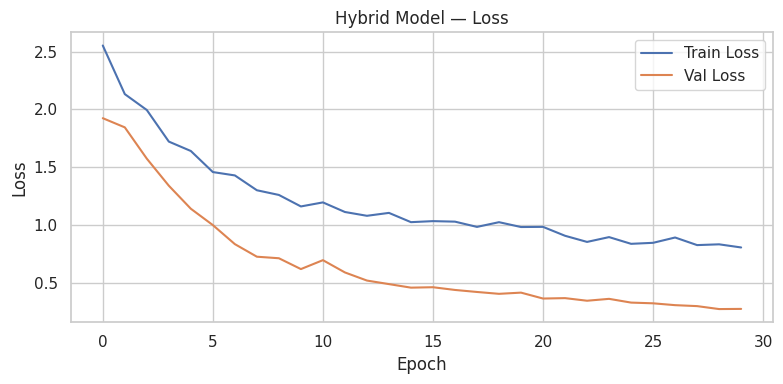

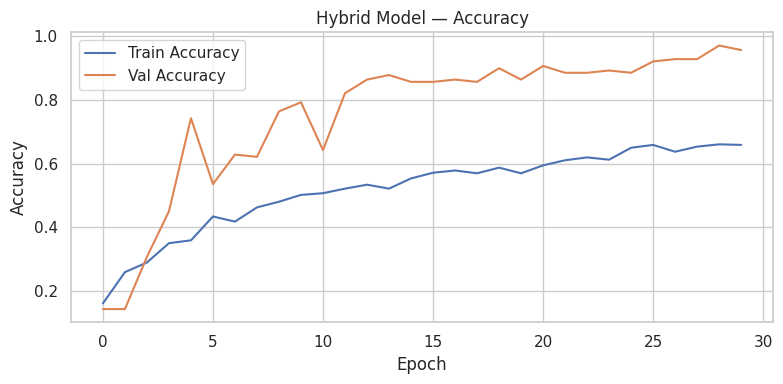

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 959ms/step

Hybrid Model — Classification Results
-------------------------------------------------------
  Accuracy        : 0.9714
  Weighted F1     : 0.9713

               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00        20
 bark_average       1.00      0.95      0.97        20
bark_ordinary       0.95      1.00      0.98        20
 bark_special       1.00      0.85      0.92        20
bark_superior       0.87      1.00      0.93        20
    leaf_fail       1.00      1.00      1.00        20
    leaf_pass       1.00      1.00      1.00        20

     accuracy                           0.97       140
    macro avg       0.97      0.97      0.97       140
 weighted avg       0.97      0.97      0.97       140



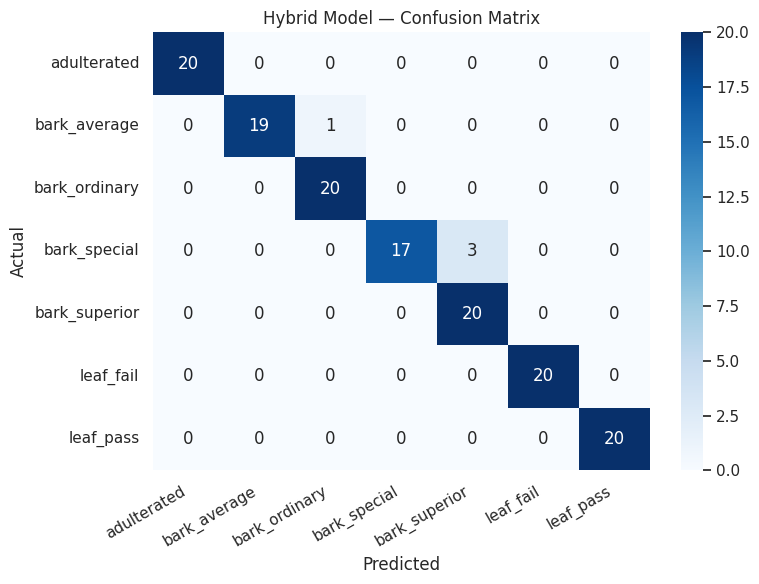

In [45]:
plot_history(hybrid_history, 'Hybrid Model')

hybrid_result = None

if USE_HYBRID_MODEL:
    hybrid_preds_raw = hybrid_model.predict([X_val_h_img, X_val_h_tab])
    hybrid_preds     = np.argmax(hybrid_preds_raw, axis=1)

    hybrid_result = evaluate_classification(y_val_hybrid, hybrid_preds, 'Hybrid Model')
else:
    print('Hybrid model skipped.')

## 33. Compare all models

In [46]:
all_results = list(tabular_results)

if image_result  is not None: all_results.append(image_result)
if hybrid_result is not None: all_results.append(hybrid_result)

comparison_df = pd.DataFrame(all_results).sort_values('f1', ascending=False)

print('Model comparison (sorted by Weighted F1):')
display(comparison_df)

best_overall_name = comparison_df.iloc[0]['model']
print('\nBest overall model:', best_overall_name)

Model comparison (sorted by Weighted F1):


,model,accuracy,f1
0,RandomForest,1.000000,1.000000
1,XGBoost,1.000000,1.000000
2,CatBoost,1.000000,1.000000
4,Hybrid Model,0.971429,0.971303
3,Image Model,0.142857,0.035714



Best overall model: RandomForest


## 34. Save final model & export package

In [47]:
EXPORT_DIR = '/content/final_export'
os.makedirs(EXPORT_DIR, exist_ok=True)

export_summary = {
    'problem_type'      : 'classification',
    'target_column'     : TARGET_COLUMN,
    'image_column'      : IMAGE_COLUMN,
    'numerical_features': NUMERICAL_FEATURES,
    'class_names'       : CLASS_NAMES,
    'best_overall_model': best_overall_name,
}

# Best tabular model
tab_path = os.path.join(EXPORT_DIR, 'best_tabular_model.pkl')
joblib.dump(best_tabular_model, tab_path)
export_summary['best_tabular_model'] = {
    'name': best_tabular_model_name, 'path': tab_path
}
print('Saved:', tab_path)

# Image model (if trained)
if USE_IMAGE_MODEL:
    img_export_path = os.path.join(EXPORT_DIR, 'best_image_model.keras')
    image_model.save(img_export_path)
    export_summary['best_image_model'] = {'name': 'Image Model', 'path': img_export_path}
    print('Saved:', img_export_path)

# Hybrid model (if trained)
if USE_HYBRID_MODEL:
    hyb_export_path = os.path.join(EXPORT_DIR, 'best_hybrid_model.keras')
    hybrid_model.save(hyb_export_path)
    export_summary['best_hybrid_model'] = {'name': 'Hybrid Model', 'path': hyb_export_path}
    print('Saved:', hyb_export_path)

# Label encoder
le_path = os.path.join(EXPORT_DIR, 'label_encoder.pkl')
joblib.dump(label_encoder, le_path)
export_summary['label_encoder'] = le_path
print('Saved:', le_path)

# Tabular preprocessor
pp_path = os.path.join(EXPORT_DIR, 'tabular_preprocessor.pkl')
joblib.dump(preprocessor, pp_path)
export_summary['tabular_preprocessor'] = pp_path
print('Saved:', pp_path)

# Hybrid preprocessor (if used)
if USE_HYBRID_MODEL:
    hpp_path = os.path.join(EXPORT_DIR, 'hybrid_tabular_preprocessor.pkl')
    joblib.dump(hybrid_preprocessor, hpp_path)
    export_summary['hybrid_tabular_preprocessor'] = hpp_path
    print('Saved:', hpp_path)

# Model comparison CSV
cmp_path = os.path.join(EXPORT_DIR, 'model_comparison.csv')
comparison_df.to_csv(cmp_path, index=False)
export_summary['model_comparison'] = cmp_path
print('Saved:', cmp_path)

# Summary JSON
with open(os.path.join(EXPORT_DIR, 'model_summary.json'), 'w') as f:
    json.dump(export_summary, f, indent=4)

print('\nAll exports done →', EXPORT_DIR)

Saved: /content/final_export/best_tabular_model.pkl
Saved: /content/final_export/best_image_model.keras
Saved: /content/final_export/best_hybrid_model.keras
Saved: /content/final_export/label_encoder.pkl
Saved: /content/final_export/tabular_preprocessor.pkl
Saved: /content/final_export/hybrid_tabular_preprocessor.pkl
Saved: /content/final_export/model_comparison.csv

All exports done → /content/final_export


## 35. Save predictions CSV

In [48]:
if best_overall_name in trained_tabular_models:
    final_preds = trained_tabular_models[best_overall_name].predict(X_val_tab)
    pred_df = X_val_tab.copy()
    pred_df['actual_encoded']    = y_val
    pred_df['predicted_encoded'] = final_preds
    pred_df['actual_label']      = label_encoder.inverse_transform(y_val.astype(int))
    pred_df['predicted_label']   = label_encoder.inverse_transform(final_preds.astype(int))

elif best_overall_name == 'Image Model':
    raw  = image_model.predict(val_img_ds)
    pred = np.argmax(raw, axis=1)
    pred_df = val_img_df[[IMAGE_COLUMN, 'density', 'ph_value', TARGET_COLUMN]].copy()
    pred_df['actual_encoded']    = y_val_img_true
    pred_df['predicted_encoded'] = pred
    pred_df['actual_label']      = label_encoder.inverse_transform(y_val_img_true.astype(int))
    pred_df['predicted_label']   = label_encoder.inverse_transform(pred.astype(int))

elif best_overall_name == 'Hybrid Model':
    raw  = hybrid_model.predict([X_val_h_img, X_val_h_tab])
    pred = np.argmax(raw, axis=1)
    pred_df = val_hybrid_df[[IMAGE_COLUMN, 'density', 'ph_value', TARGET_COLUMN]].copy()
    pred_df['actual_encoded']    = y_val_hybrid
    pred_df['predicted_encoded'] = pred
    pred_df['actual_label']      = label_encoder.inverse_transform(y_val_hybrid.astype(int))
    pred_df['predicted_label']   = label_encoder.inverse_transform(pred.astype(int))

pred_path = os.path.join(OUTPUT_DIR, 'predictions.csv')
pred_df.to_csv(pred_path, index=False)

print('Saved predictions →', pred_path)
display(pred_df.head(10))

Saved predictions → /content/outputs/predictions.csv


,density,ph_value,actual_encoded,predicted_encoded,actual_label,predicted_label
686,1.004,4.41,0,0,adulterated,adulterated
457,1.018,4.94,6,6,leaf_pass,leaf_pass
236,1.029,5.17,1,1,bark_average,bark_average
469,1.019,4.93,6,6,leaf_pass,leaf_pass
185,1.035,5.31,3,3,bark_special,bark_special
620,1.002,4.57,0,0,adulterated,adulterated
352,1.022,5.08,2,2,bark_ordinary,bark_ordinary
195,1.037,5.30,3,3,bark_special,bark_special
495,1.018,4.91,6,6,leaf_pass,leaf_pass
175,1.037,5.29,3,3,bark_special,bark_special


## 36. Single-sample prediction helper

In [49]:
def predict_oil_type(density: float, ph_value: float, image_path: str = None) -> dict:
    """
    Predict cinnamon oil type from density, ph_value, and an optional image.

    Returns a dict with:
      - predicted_label  : one of bark_superior / bark_special / bark_average /
                           bark_ordinary / leaf_pass / leaf_fail / adulterated
      - confidence       : probability of the predicted class (best tabular model)
      - all_probabilities: dict of class → probability
    """
    sample = pd.DataFrame([{'density': density, 'ph_value': ph_value}])

    # Use best tabular model
    model = trained_tabular_models[best_tabular_model_name]
    pred_idx  = model.predict(sample)[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    proba_dict = {}
    confidence = None
    if hasattr(model, 'predict_proba'):
        probas = model.predict_proba(sample)[0]
        proba_dict = {label_encoder.classes_[i]: round(float(p), 4)
                      for i, p in enumerate(probas)}
        confidence = round(float(probas[pred_idx]), 4)

    return {
        'predicted_label' : pred_label,
        'confidence'      : confidence,
        'all_probabilities': proba_dict,
    }


# ── Quick test ─────────────────────────────────────────────────────────────
test_result = predict_oil_type(density=1.042, ph_value=5.35)
print('Test prediction:')
print(f'  Input   : density=1.042, ph_value=5.35')
print(f'  Result  : {test_result["predicted_label"]}')
print(f'  Confidence: {test_result["confidence"]}')
print(f'  All probabilities:')
for cls, p in test_result['all_probabilities'].items():
    print(f'    {cls:20s}: {p:.4f}')

Test prediction:
  Input   : density=1.042, ph_value=5.35
  Result  : bark_superior
  Confidence: 0.99
  All probabilities:
    adulterated         : 0.0000
    bark_average        : 0.0000
    bark_ordinary       : 0.0000
    bark_special        : 0.0100
    bark_superior       : 0.9900
    leaf_fail           : 0.0000
    leaf_pass           : 0.0000


## 37. Zip & download all models

In [50]:
!zip -r final_cinnamon_oil_models.zip /content/final_export
print('Archive created: final_cinnamon_oil_models.zip')

  adding: content/final_export/ (stored 0%)
  adding: content/final_export/best_image_model.keras (deflated 11%)
  adding: content/final_export/best_tabular_model.pkl (deflated 85%)
  adding: content/final_export/label_encoder.pkl (deflated 51%)
  adding: content/final_export/model_comparison.csv (deflated 39%)
  adding: content/final_export/hybrid_tabular_preprocessor.pkl (deflated 50%)
  adding: content/final_export/best_hybrid_model.keras (deflated 11%)
  adding: content/final_export/tabular_preprocessor.pkl (deflated 50%)
  adding: content/final_export/model_summary.json (deflated 69%)
Archive created: final_cinnamon_oil_models.zip


In [51]:
from google.colab import files
files.download('final_cinnamon_oil_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>